# Exponential smoothing in state-space form with `pymc_forecast`

This notebook ports the upstream NumPyro exponential-smoothing state-space example to PyMC.
The model is a damped Holt-Winters single-source-of-error system: one innovation updates
level, trend, and seasonality, and future innovations are fed back into the forecast state.

The custom recursion is written with `pytensor.scan`, while fitting and forecasting use
`HMCForecaster` and the same posterior predictive replay mechanism as the rest of the package.


## Prepare notebook


In [1]:
import logging
import os
from functools import partial

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor
import pytensor.tensor as pt
import xarray as xr

from pymc_forecast import (
    HMCForecaster,
    Horizon,
    eval_coverage,
    eval_crps,
    eval_mae,
    eval_rmse,
    evaluate_forecast,
    null_covariates,
)
from pymc_forecast.data import FUTURE_DIM, TIME_DIM

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

logging.getLogger("pymc").setLevel(logging.ERROR)
logging.getLogger("pytensor").setLevel(logging.ERROR)

SEED = 42
rng = np.random.default_rng(SEED)

# CI executes every example notebook end-to-end with reduced settings.
SMOKE_TEST = os.environ.get("PYMC_FORECAST_SMOKE_TEST", "0") == "1"
DRAWS = 50 if SMOKE_TEST else 1_000
TUNE = 50 if SMOKE_TEST else 1_000
CHAINS = 2 if SMOKE_TEST else 4

## Generate synthetic data

The synthetic series follows the upstream example: a seasonal cosine wave, a slow logarithmic
trend, and Gaussian noise. The seasonal state length is `m = 15`.


In [2]:
n_seasons = 15
t = np.linspace(0, n_seasons + 1, (n_seasons + 1) * n_seasons)
y = np.cos(2 * np.pi * t) + np.log(t + 1) + 0.2 * rng.normal(size=t.shape)

n = len(y)
n_train = int(0.8 * n)
future = n - n_train

train_data = xr.DataArray(y[:n_train], dims=(TIME_DIM,), coords={TIME_DIM: t[:n_train]})
test_data = xr.DataArray(y[n_train:], dims=(TIME_DIM,), coords={TIME_DIM: t[n_train:]})
covariates_full = null_covariates(t)
covariates_train = covariates_full.isel({TIME_DIM: slice(None, n_train)})

print(f"total: {n}, train: {n_train}, test horizon: {future}")

total: 240, train: 192, test horizon: 48


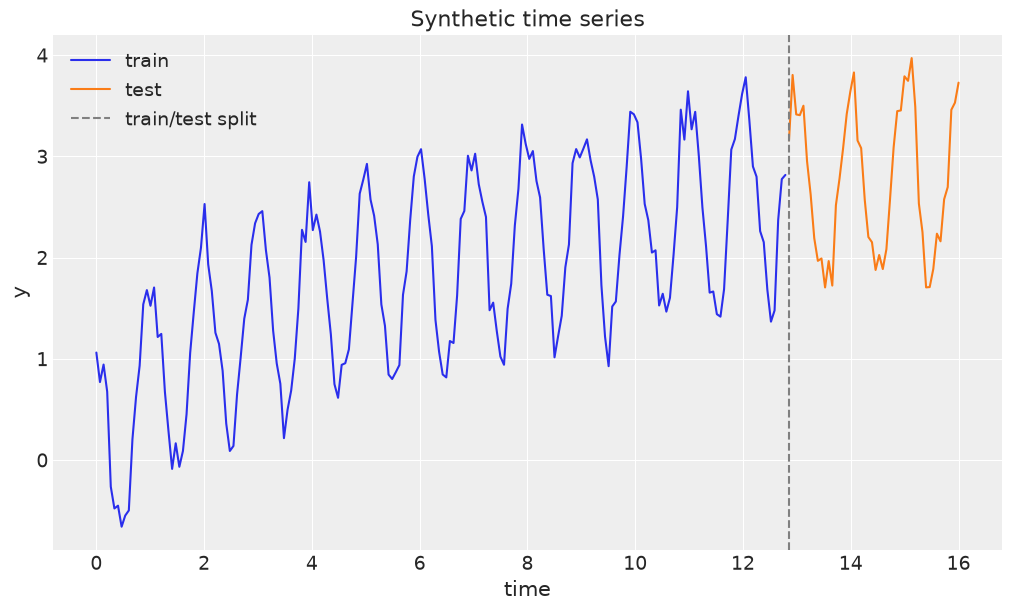

In [3]:
fig, ax = plt.subplots()
ax.plot(train_data[TIME_DIM].values, train_data.values, color="C0", label="train")
ax.plot(test_data[TIME_DIM].values, test_data.values, color="C1", label="test")
ax.axvline(test_data[TIME_DIM].values[0], color="gray", linestyle="--", label="train/test split")
ax.legend(loc="upper left")
ax.set(title="Synthetic time series", xlabel="time", ylabel="y")
plt.show()

## Damping sums

Damped trend forecasts repeatedly add powers of the damping parameter. The finite sum below
is the scan-like quantity that appears in the state-space recursion.


In [4]:
def damping_sum(phi: float, horizon: int) -> tuple[float, np.ndarray]:
    powers = phi ** np.arange(1, horizon + 1)
    partial_sums = np.cumsum(powers)
    return float(partial_sums[-1]), partial_sums


phi_example = 0.8
total, partial_sums = damping_sum(phi_example, 5)
closed_form = sum(phi_example**i for i in range(1, 6))
print(f"scan-style result: {total:.5f}")
print(f"closed form:       {closed_form:.5f}")
print(f"partial sums:      {partial_sums.round(5)}")

scan-style result: 2.68928
closed form:       2.68928
partial sums:      [0.8     1.44    1.952   2.3616  2.68928]


## Model

The in-sample scan computes one-step-ahead means and innovations from observed data. During
forecasting, `eps_future` is absent from the fitted trace, so posterior predictive sampling
draws fresh future innovations and feeds them through the same state update.


In [5]:
def exponential_smoothing_ssm(h: Horizon, covariates: xr.DataArray) -> None:
    """Damped Holt-Winters exponential smoothing in innovations state-space form."""
    if h.data is None:
        msg = "the exponential smoothing model requires observed data"
        raise ValueError(msg)

    y_obs_np = np.asarray(h.data.values, dtype="float64")
    y_obs = pt.as_tensor_variable(y_obs_np)

    level_smoothing = pm.Beta("level_smoothing", 5, 5)
    level_init = pm.Normal("level_init", float(y_obs_np[0]), 1.0)
    trend_smoothing = pm.Beta("trend_smoothing", 5, 5)
    trend_init = pm.Normal("trend_init", 0.0, 0.1)
    seasonality_smoothing = pm.Beta("seasonality_smoothing", 5, 5)
    phi = pm.Beta("phi", 2, 5)
    seasonality_init = pm.Normal("seasonality_init", 0.0, 1.0, shape=n_seasons)
    noise = pm.HalfNormal("noise", 0.5)

    beta = trend_smoothing * level_smoothing
    gamma = seasonality_smoothing * (1.0 - level_smoothing)

    def train_step(y_t, level, trend, seasonality, alpha, beta, gamma, phi):
        mu_t = level + phi * trend + seasonality[0]
        innovation = y_t - mu_t
        new_level = level + phi * trend + alpha * innovation
        new_trend = phi * trend + beta * innovation
        new_season = seasonality[0] + gamma * innovation
        new_seasonality = pt.concatenate([seasonality[1:], new_season[None]])
        return new_level, new_trend, new_seasonality, mu_t

    level_hist, trend_hist, seasonality_hist, mu = pytensor.scan(
        fn=train_step,
        sequences=[y_obs],
        outputs_info=[level_init, trend_init, seasonality_init, None],
        non_sequences=[level_smoothing, beta, gamma, phi],
        strict=True,
        return_updates=False,
    )
    pm.Deterministic("mu", mu, dims=TIME_DIM)
    pm.Normal("obs", mu=mu, sigma=noise, observed=y_obs_np, dims=TIME_DIM)

    if h.future > 0:
        eps_future = pm.Normal("eps_future", 0.0, noise, dims=FUTURE_DIM)

        def forecast_step(eps_t, level, trend, seasonality, alpha, beta, gamma, phi):
            mu_t = level + phi * trend + seasonality[0]
            y_t = mu_t + eps_t
            new_level = level + phi * trend + alpha * eps_t
            new_trend = phi * trend + beta * eps_t
            new_season = seasonality[0] + gamma * eps_t
            new_seasonality = pt.concatenate([seasonality[1:], new_season[None]])
            return new_level, new_trend, new_seasonality, y_t

        _, _, _, forecast = pytensor.scan(
            fn=forecast_step,
            sequences=[eps_future],
            outputs_info=[level_hist[-1], trend_hist[-1], seasonality_hist[-1], None],
            non_sequences=[level_smoothing, beta, gamma, phi],
            strict=True,
            return_updates=False,
        )
        pm.Deterministic("forecast", forecast, dims=FUTURE_DIM)

## Priors


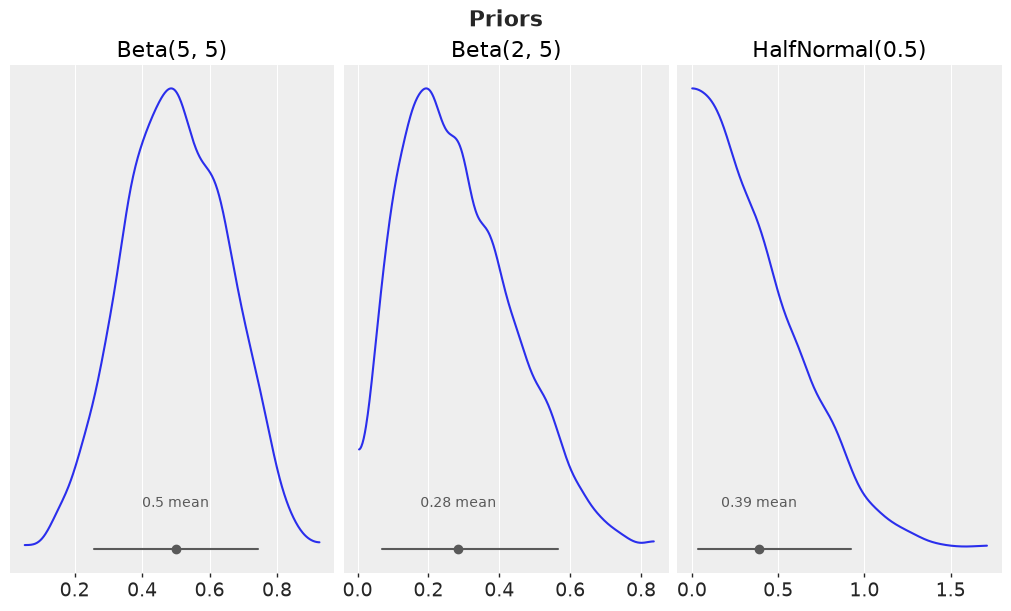

In [6]:
prior_parameter_idata = az.from_dict(
    {
        "prior": {
            "Beta(5, 5)": pm.draw(pm.Beta.dist(5, 5), draws=5_000, random_seed=SEED)[None, :],
            "Beta(2, 5)": pm.draw(pm.Beta.dist(2, 5), draws=5_000, random_seed=SEED + 1)[
                None,
                :,
            ],
            "HalfNormal(0.5)": pm.draw(
                pm.HalfNormal.dist(0.5),
                draws=5_000,
                random_seed=SEED + 2,
            )[None, :],
        }
    }
)
pc = az.plot_dist(
    prior_parameter_idata,
    var_names=["Beta(5, 5)", "Beta(2, 5)", "HalfNormal(0.5)"],
    group="prior",
    figure_kwargs={"figsize": (10, 6)},
)
pc.viz["figure"].item().suptitle("Priors", fontsize=16, fontweight="bold")
plt.show()

## Inference

`HMCForecaster` wraps `pm.sample`. The schedule below is moderate for an example; increase
`draws` and `tune` if you want publication-quality diagnostics.


In [7]:
forecaster = HMCForecaster(
    exponential_smoothing_ssm,
    train_data,
    covariates_train,
    draws=DRAWS,
    tune=TUNE,
    chains=CHAINS,
    random_seed=SEED,
    sample_kwargs={"target_accept": 0.9},
)

## Diagnostics


In [8]:
scalar_vars = [
    "level_smoothing",
    "trend_smoothing",
    "seasonality_smoothing",
    "phi",
    "noise",
    "level_init",
    "trend_init",
]
az.summary(forecaster.idata, var_names=scalar_vars, round_to=2)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
level_smoothing,0.32,0.06,0.22,0.42,2550.33,2526.28,1.00,0.00,0.00
trend_smoothing,0.47,0.15,0.24,0.71,3170.16,2625.21,1.00,0.00,0.00
seasonality_smoothing,0.22,0.07,0.11,0.35,1441.29,1746.64,1.00,0.00,0.00
phi,0.19,0.12,0.04,0.41,2444.20,1990.43,1.00,0.00,0.00
noise,0.22,0.01,0.20,0.24,2019.24,2422.94,1.00,0.00,0.00
level_init,0.26,0.30,-0.22,0.72,514.49,725.06,1.01,0.01,0.01
trend_init,0.00,0.10,-0.16,0.16,3002.17,2480.78,1.00,0.00,0.00


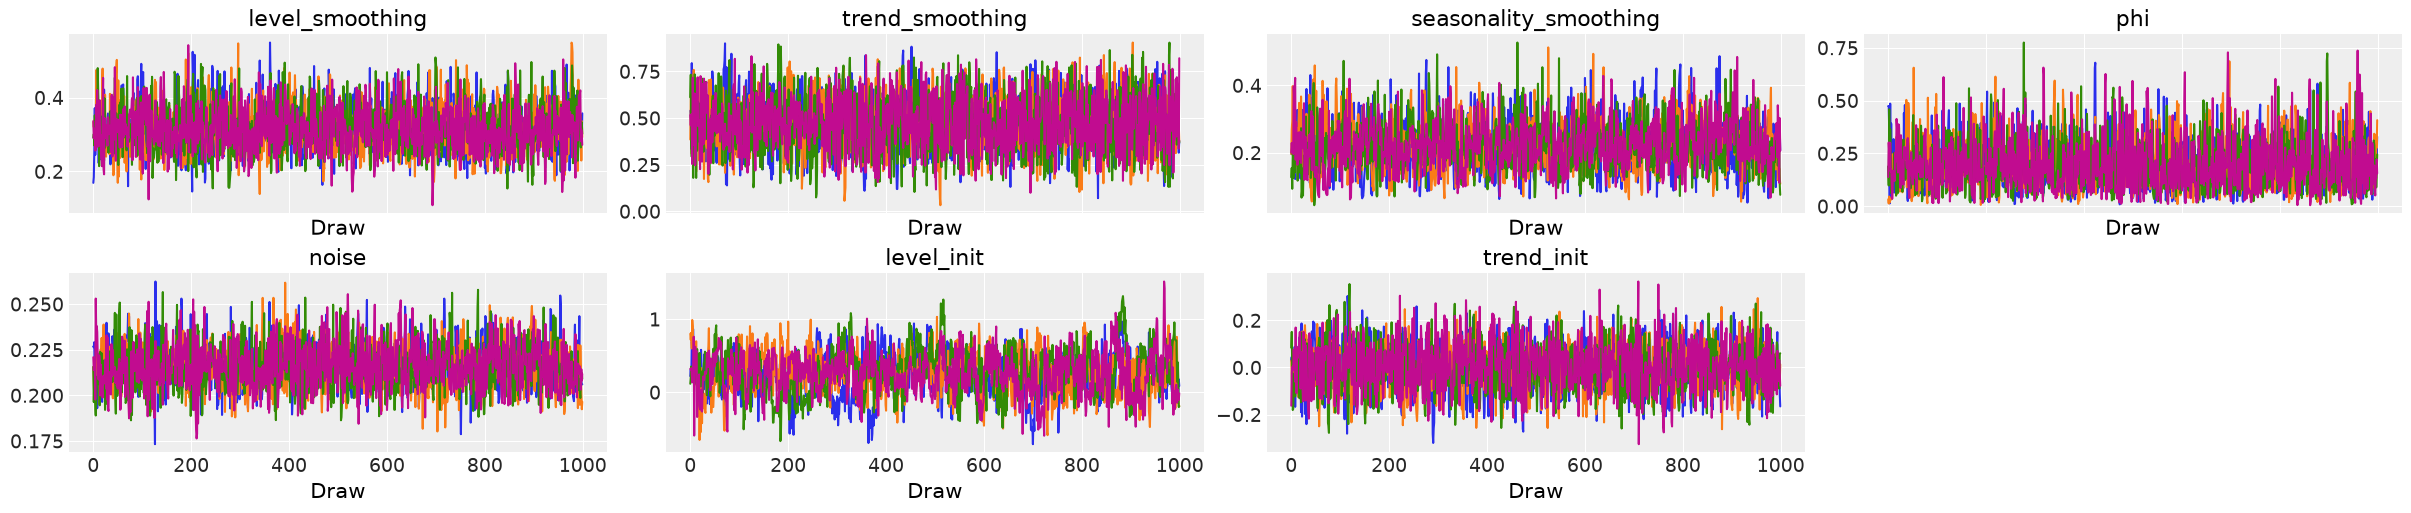

In [9]:
az.plot_trace(forecaster.idata, var_names=scalar_vars)
plt.show()

## Forecast


In [10]:
NUM_FORECAST_SAMPLES = 50 if SMOKE_TEST else 1_000

forecast_idata = forecaster.forecast(
    covariates_full,
    num_samples=NUM_FORECAST_SAMPLES,
    random_seed=SEED,
    progressbar=False,
)
in_sample_idata = forecaster.predict_in_sample(
    num_samples=NUM_FORECAST_SAMPLES,
    random_seed=SEED,
    progressbar=False,
)
in_sample_idata["constant_data"] = xr.Dataset(
    {"t_value": (TIME_DIM, train_data[TIME_DIM].values)},
    coords={TIME_DIM: train_data[TIME_DIM].values},
)

in_sample_pp = in_sample_idata["posterior_predictive"]["obs"]
forecast_samples = forecast_idata["predictions"]["forecast"]
test_truth = test_data.rename({TIME_DIM: FUTURE_DIM})
forecast_lm_idata = az.from_dict(
    {
        "posterior_predictive": {"obs": forecast_samples.values},
        "observed_data": {"obs": test_truth.values},
        "constant_data": {"t_value": test_truth[FUTURE_DIM].values},
    },
    coords={TIME_DIM: test_truth[FUTURE_DIM].values},
    dims={"obs": [TIME_DIM], "t_value": [TIME_DIM]},
)

print("in-sample posterior predictive:", in_sample_pp.sizes)
print("forecast samples:", forecast_samples.sizes)

in-sample posterior predictive: Frozen({'chain': 1, 'draw': 1000, 'time': 192})
forecast samples: Frozen({'chain': 1, 'draw': 1000, 'time_future': 48})


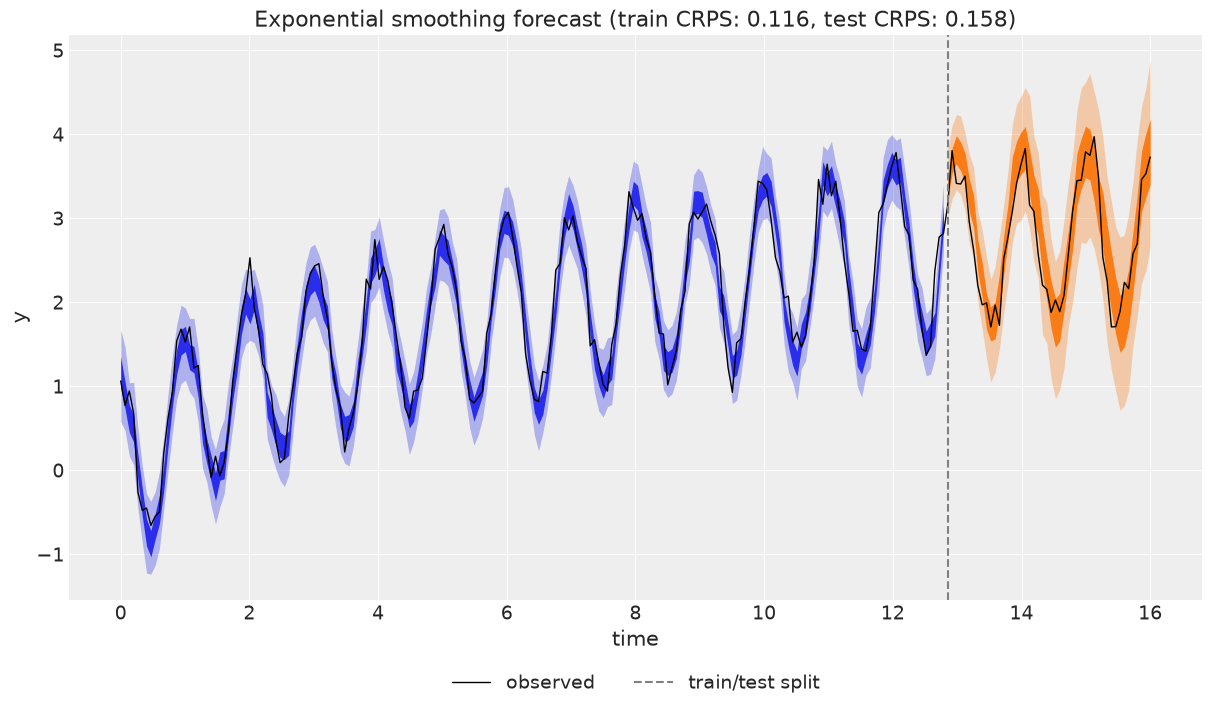

In [11]:
train_crps = eval_crps(in_sample_pp, train_data)
test_crps = eval_crps(forecast_samples, test_truth)
title = f"Exponential smoothing forecast (train CRPS: {train_crps:.3f}, test CRPS: {test_crps:.3f})"

pc = az.plot_lm(
    in_sample_idata,
    y="obs",
    x="t_value",
    ci_kind="hdi",
    ci_prob=(0.5, 0.94),
    smooth=False,
    visuals={"ci_band": {"color": "C0"}, "observed_scatter": False, "pe_line": False},
    figure_kwargs={"figsize": (12, 7)},
)
az.plot_lm(
    forecast_lm_idata,
    y="obs",
    x="t_value",
    plot_collection=pc,
    ci_kind="hdi",
    ci_prob=(0.5, 0.94),
    smooth=False,
    visuals={"ci_band": {"color": "C1"}, "observed_scatter": False, "pe_line": False},
)
ax = pc.viz["figure"].item().axes[0]
ax.plot(t, y, color="black", lw=1, label="observed")
ax.axvline(test_data[TIME_DIM].values[0], color="gray", linestyle="--", label="train/test split")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3)
ax.set(title=title, xlabel="time", ylabel="y")
plt.show()

## Evaluation


In [12]:
metrics = {
    "MAE": eval_mae,
    "RMSE": eval_rmse,
    "CRPS": eval_crps,
    "coverage_90": partial(eval_coverage, alpha=0.9),
}
pd.Series(evaluate_forecast(forecast_samples, test_truth, metrics=metrics)).round(4)

MAE            0.2045
RMSE           0.2536
CRPS           0.1578
coverage_90    1.0000
dtype: float64

## References

- Upstream NumPyro notebook: https://github.com/juanitorduz/numpyro_forecast/blob/main/docs/examples/exponential_smoothing_state_space.ipynb
- Hyndman et al., Forecasting with Exponential Smoothing: The State Space Approach.
